# HW12: Forecasting with Temporal Split, Baselines and GRU

В ноутбуке реализованы все обязательные части HW12:
- первичный анализ временного ряда;
- корректный `temporal split` без перемешивания;
- baseline-эксперименты `B1`, `B2`, `B3`;
- нейросетевой прогноз `R1` на основе `GRU`;
- сохранение артефактов и автогенерация `report.md`.


## 1. Импорты, seed, среда и папки для артефактов


In [1]:
import csv
import json
import math
import random
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

%matplotlib inline
plt.style.use("ggplot")

ROOT = Path(".")
DATA_PATH = ROOT / "S12-hw-dataset.csv"
ARTIFACTS_DIR = ROOT / "artifacts"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
ARTIFACTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
print(f"Seed: {SEED}")
print(f"Dataset path: {DATA_PATH.resolve()}")


Device: cpu
Seed: 42
Dataset path: C:\Users\vt240\OneDrive\Рабочий стол\prog\II-cafedra\aie-student-template\homeworks\HW12\S12-hw-dataset.csv


## 2. Загрузка данных и первичный анализ


In [2]:
df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Rows:", len(df))
print("Date range:", df["date"].min(), "->", df["date"].max())
print("Missing values by column:")
print(df.isna().sum())
print("Target describe:")
print(df["target"].describe())

df.head()


Rows: 4320
Date range: 2025-01-01 00:00:00 -> 2025-06-29 23:00:00
Missing values by column:
date      0
target    0
dtype: int64
Target describe:
count    4320.000000
mean      135.605840
std        21.384633
min        69.100000
25%       120.537500
50%       135.835000
75%       150.625000
max       210.100000
Name: target, dtype: float64


,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


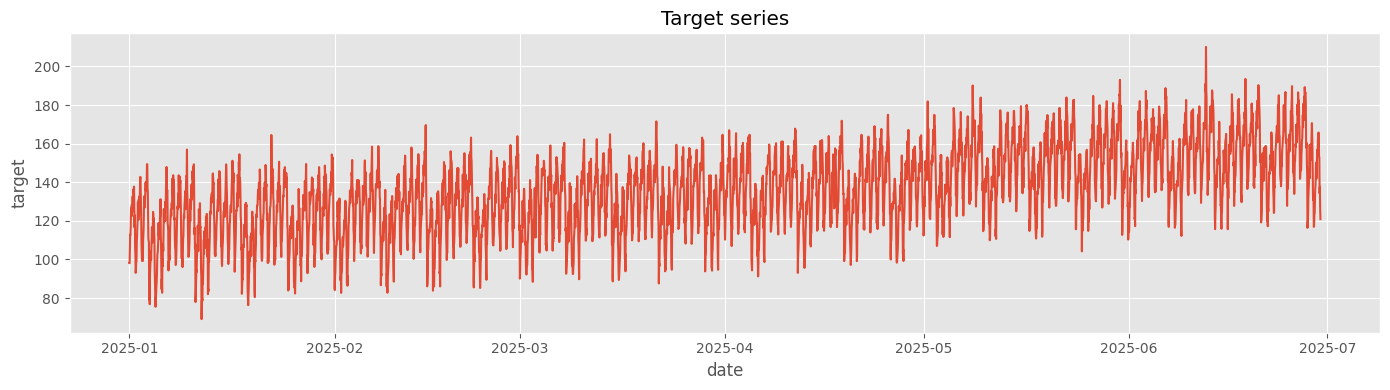

Ряд выглядит нестационарным: заметны колебания уровня и выраженная повторяемость, что похоже на сезонный компонент. Явных пропусков нет, поэтому дополнительная импутация не требуется. Для такого ряда random split некорректен, потому что он смешивает прошлое и будущее и делает оценку слишком оптимистичной.


In [3]:
plt.figure(figsize=(14, 4))
plt.plot(df["date"], df["target"], linewidth=1.5)
plt.title("Target series")
plt.xlabel("date")
plt.ylabel("target")
plt.tight_layout()
plt.show()

series_comment = (
    "Ряд выглядит нестационарным: заметны колебания уровня и выраженная повторяемость, "
    "что похоже на сезонный компонент. Явных пропусков нет, поэтому дополнительная "
    "импутация не требуется. Для такого ряда random split некорректен, потому что он "
    "смешивает прошлое и будущее и делает оценку слишком оптимистичной."
)
print(series_comment)


## 3. Temporal split: train / validation / test


In [4]:
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15
assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9

n = len(df)
train_end = int(n * train_ratio)
val_end = int(n * (train_ratio + val_ratio))

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

split_summary = {
    "train": {
        "rows": len(train_df),
        "date_from": str(train_df["date"].min()),
        "date_to": str(train_df["date"].max()),
    },
    "validation": {
        "rows": len(val_df),
        "date_from": str(val_df["date"].min()),
        "date_to": str(val_df["date"].max()),
    },
    "test": {
        "rows": len(test_df),
        "date_from": str(test_df["date"].min()),
        "date_to": str(test_df["date"].max()),
    },
}

print(json.dumps(split_summary, indent=2, ensure_ascii=False))


{
  "train": {
    "rows": 3024,
    "date_from": "2025-01-01 00:00:00",
    "date_to": "2025-05-06 23:00:00"
  },
  "validation": {
    "rows": 648,
    "date_from": "2025-05-07 00:00:00",
    "date_to": "2025-06-02 23:00:00"
  },
  "test": {
    "rows": 648,
    "date_from": "2025-06-03 00:00:00",
    "date_to": "2025-06-29 23:00:00"
  }
}


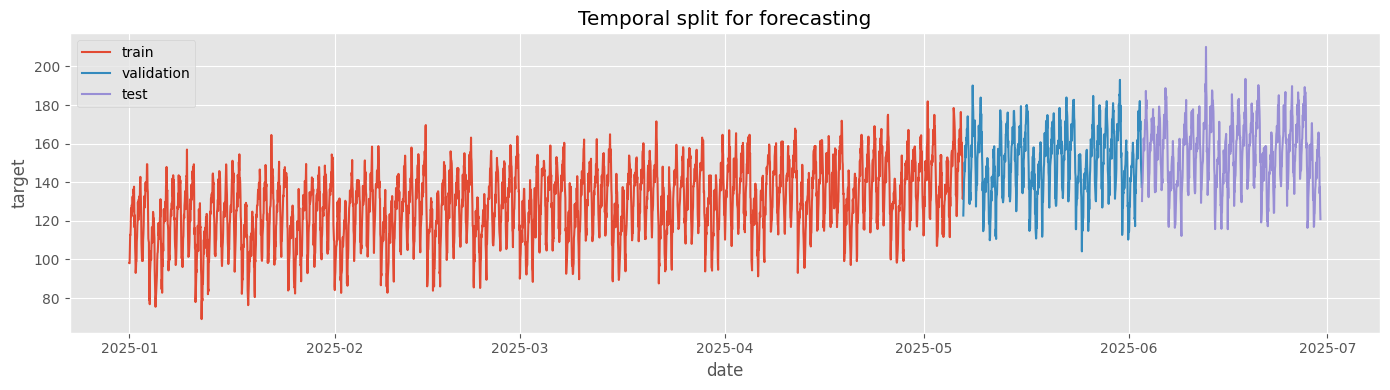

Почему random split некорректен: в прогнозировании мы должны учиться только на прошлом и проверяться на будущем. Случайное перемешивание переносит информацию из будущих участков в train и создаёт утечку, особенно для лагов, rolling-признаков и сезонности.


In [5]:
plt.figure(figsize=(14, 4))
plt.plot(train_df["date"], train_df["target"], label="train", linewidth=1.5)
plt.plot(val_df["date"], val_df["target"], label="validation", linewidth=1.5)
plt.plot(test_df["date"], test_df["target"], label="test", linewidth=1.5)
plt.title("Temporal split for forecasting")
plt.xlabel("date")
plt.ylabel("target")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "series_split.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    "Почему random split некорректен: в прогнозировании мы должны учиться только на прошлом "
    "и проверяться на будущем. Случайное перемешивание переносит информацию из будущих участков "
    "в train и создаёт утечку, особенно для лагов, rolling-признаков и сезонности."
)


## 4. Признаки для baseline-моделей


In [6]:
def make_time_features(frame):
    out = frame.copy()
    out["lag_1"] = out["target"].shift(1)
    out["lag_7"] = out["target"].shift(7)
    out["lag_14"] = out["target"].shift(14)
    out["rolling_mean_7"] = out["target"].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out["target"].shift(1).rolling(window=7).std()
    out["day_of_week"] = out["date"].dt.dayofweek
    out["hour"] = out["date"].dt.hour
    out["is_weekend"] = (out["day_of_week"] >= 5).astype(int)
    return out

feature_df = make_time_features(df)
feature_columns = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "day_of_week",
    "hour",
    "is_weekend",
]

print("Feature columns:", feature_columns)
print("NaNs after feature engineering:")
print(feature_df[feature_columns].isna().sum())
feature_df.head(10)


Feature columns: ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'hour', 'is_weekend']
NaNs after feature engineering:
lag_1              1
lag_7              7
lag_14            14
rolling_mean_7     7
rolling_std_7      7
day_of_week        0
hour               0
is_weekend         0
dtype: int64


,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,day_of_week,hour,is_weekend
0,2025-01-01 00:00:00,98.14,NaN,NaN,NaN,NaN,NaN,2,0,0
1,2025-01-01 01:00:00,98.07,98.14,NaN,NaN,NaN,NaN,2,1,0
2,2025-01-01 02:00:00,104.70,98.07,NaN,NaN,NaN,NaN,2,2,0
3,2025-01-01 03:00:00,112.81,104.70,NaN,NaN,NaN,NaN,2,3,0
4,2025-01-01 04:00:00,112.62,112.81,NaN,NaN,NaN,NaN,2,4,0
5,2025-01-01 05:00:00,117.29,112.62,NaN,NaN,NaN,NaN,2,5,0
6,2025-01-01 06:00:00,126.50,117.29,NaN,NaN,NaN,NaN,2,6,0
7,2025-01-01 07:00:00,126.01,126.50,98.14,NaN,110.018571,10.418147,2,7,0
8,2025-01-01 08:00:00,122.38,126.01,98.07,NaN,114.000000,10.447405,2,8,0
9,2025-01-01 09:00:00,128.28,122.38,104.70,NaN,117.472857,8.030400,2,9,0


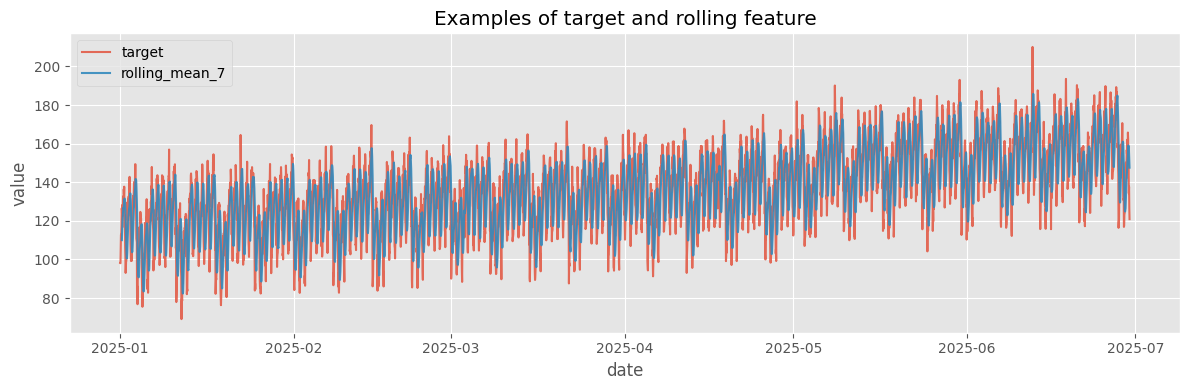

Утечки данных избегаются так: все lag- и rolling-признаки строятся только через shift(1), поэтому для строки t используются только значения до t-1. Масштабирование для B3 и R1 обучается только на train.


In [7]:
plt.figure(figsize=(12, 4))
plt.plot(feature_df["date"], feature_df["target"], label="target", alpha=0.8)
plt.plot(feature_df["date"], feature_df["rolling_mean_7"], label="rolling_mean_7", alpha=0.9)
plt.title("Examples of target and rolling feature")
plt.xlabel("date")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_examples.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    "Утечки данных избегаются так: все lag- и rolling-признаки строятся только через shift(1), "
    "поэтому для строки t используются только значения до t-1. Масштабирование для B3 и R1 "
    "обучается только на train."
)


## 5. Метрики и baseline-эксперименты B1, B2, B3


In [8]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, 1e-8, np.abs(y_true))
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    denom = np.where(denom < 1e-8, 1e-8, denom)
    return float(np.mean(2 * np.abs(y_pred - y_true) / denom) * 100)

def calc_metrics(y_true, y_pred):
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": rmse(y_true, y_pred),
        "mape": mape(y_true, y_pred),
        "smape": smape(y_true, y_pred),
    }

def build_result(experiment_id, model_summary, features_summary, scaler, optimizer="", lr="", epochs_trained="", notes=""):
    return {
        "experiment_id": experiment_id,
        "task": "forecasting",
        "dataset": DATA_PATH.name,
        "seed": SEED,
        "split_summary": json.dumps(split_summary, ensure_ascii=False),
        "window_size": "",
        "horizon": 1,
        "model_summary": model_summary,
        "features_summary": features_summary,
        "scaler": scaler,
        "optimizer": optimizer,
        "lr": lr,
        "epochs_trained": epochs_trained,
        "best_val_mae": "",
        "best_val_rmse": "",
        "best_val_mape": "",
        "test_mae": "",
        "test_rmse": "",
        "test_mape": "",
        "notes": notes,
    }


In [9]:
results = []
predictions_store = {}

# B1: naive-last
feature_df["naive_last_pred"] = feature_df["target"].shift(1)
val_b1 = feature_df.iloc[train_end:val_end].dropna(subset=["naive_last_pred"])
val_metrics_b1 = calc_metrics(val_b1["target"], val_b1["naive_last_pred"])
result_b1 = build_result("B1", "Naive last value", "last observed target", "none", notes="Prediction equals lag_1")
result_b1["best_val_mae"] = val_metrics_b1["mae"]
result_b1["best_val_rmse"] = val_metrics_b1["rmse"]
result_b1["best_val_mape"] = val_metrics_b1["mape"]
results.append(result_b1)
predictions_store["B1"] = {
    "val_dates": val_b1["date"],
    "val_true": val_b1["target"].to_numpy(),
    "val_pred": val_b1["naive_last_pred"].to_numpy(),
}

# B2: moving-average
ma_window = 24
feature_df["moving_average_pred"] = feature_df["target"].shift(1).rolling(ma_window).mean()
val_b2 = feature_df.iloc[train_end:val_end].dropna(subset=["moving_average_pred"])
val_metrics_b2 = calc_metrics(val_b2["target"], val_b2["moving_average_pred"])
result_b2 = build_result("B2", f"Moving average ({ma_window})", f"rolling mean over previous {ma_window} points", "none", notes="No training")
result_b2["best_val_mae"] = val_metrics_b2["mae"]
result_b2["best_val_rmse"] = val_metrics_b2["rmse"]
result_b2["best_val_mape"] = val_metrics_b2["mape"]
results.append(result_b2)
predictions_store["B2"] = {
    "val_dates": val_b2["date"],
    "val_true": val_b2["target"].to_numpy(),
    "val_pred": val_b2["moving_average_pred"].to_numpy(),
}

# B3: ridge with lag features
model_df = feature_df.dropna(subset=feature_columns).copy()
train_mask = model_df.index < train_end
val_mask = (model_df.index >= train_end) & (model_df.index < val_end)
test_mask = model_df.index >= val_end

X_train = model_df.loc[train_mask, feature_columns].to_numpy()
y_train = model_df.loc[train_mask, "target"].to_numpy()
X_val = model_df.loc[val_mask, feature_columns].to_numpy()
y_val = model_df.loc[val_mask, "target"].to_numpy()

feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_val_scaled = feature_scaler.transform(X_val)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
val_pred_b3 = ridge.predict(X_val_scaled)
val_metrics_b3 = calc_metrics(y_val, val_pred_b3)
result_b3 = build_result("B3", "Ridge regression", ", ".join(feature_columns), "StandardScaler(train only)", notes="Lag, rolling and calendar features")
result_b3["best_val_mae"] = val_metrics_b3["mae"]
result_b3["best_val_rmse"] = val_metrics_b3["rmse"]
result_b3["best_val_mape"] = val_metrics_b3["mape"]
results.append(result_b3)
predictions_store["B3"] = {
    "val_dates": model_df.loc[val_mask, "date"],
    "val_true": y_val,
    "val_pred": val_pred_b3,
}

pd.DataFrame(results)


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,"{""train"": {""rows"": 3024, ""date_from"": ""2025-01...",,1,Naive last value,last observed target,none,,,,6.444815,8.201023,4.397922,,,,Prediction equals lag_1
1,B2,forecasting,S12-hw-dataset.csv,42,"{""train"": {""rows"": 3024, ""date_from"": ""2025-01...",,1,Moving average (24),rolling mean over previous 24 points,none,,,,13.397980,16.169904,9.198834,,,,No training
2,B3,forecasting,S12-hw-dataset.csv,42,"{""train"": {""rows"": 3024, ""date_from"": ""2025-01...",,1,Ridge regression,"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler(train only),,,,6.734516,8.235854,4.514981,,,,"Lag, rolling and calendar features"


## 6. Оконное представление и модель GRU (R1)


In [10]:
window_size = 24
batch_size = 64
max_epochs = 30
learning_rate = 1e-3
hidden_size = 32
num_layers = 1

class SequenceDataset(Dataset):
    def __init__(self, scaled_series, label_start, label_end, window_size):
        self.series = scaled_series.astype(np.float32)
        self.window_size = window_size
        self.indices = list(range(max(label_start, window_size), label_end))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        label_idx = self.indices[idx]
        x = self.series[label_idx - self.window_size:label_idx]
        y = self.series[label_idx]
        return torch.tensor(x).unsqueeze(-1), torch.tensor(y)

class GRUForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.head(out[:, -1, :]).squeeze(-1)

series_scaler = StandardScaler()
train_target = train_df[["target"]].to_numpy()
series_scaler.fit(train_target)
scaled_target = series_scaler.transform(df[["target"]]).reshape(-1)

train_seq_ds = SequenceDataset(scaled_target, label_start=0, label_end=train_end, window_size=window_size)
val_seq_ds = SequenceDataset(scaled_target, label_start=train_end, label_end=val_end, window_size=window_size)
test_seq_ds = SequenceDataset(scaled_target, label_start=val_end, label_end=len(df), window_size=window_size)

train_loader = DataLoader(train_seq_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_seq_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_seq_ds, batch_size=batch_size, shuffle=False)

print("Train sequences:", len(train_seq_ds))
print("Val sequences:", len(val_seq_ds))
print("Test sequences:", len(test_seq_ds))


Train sequences: 3000
Val sequences: 648
Test sequences: 648


C:\Users\vt240\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [11]:
def inverse_target_scale(values):
    values = np.asarray(values).reshape(-1, 1)
    return series_scaler.inverse_transform(values).reshape(-1)

@torch.no_grad()
def evaluate_gru(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        pred = model(x)
        loss = criterion(pred, y)
        running_loss += loss.item() * x.size(0)
        all_preds.append(pred.cpu().numpy())
        all_targets.append(y.cpu().numpy())
    avg_loss = running_loss / len(loader.dataset)
    preds = inverse_target_scale(np.concatenate(all_preds))
    targets = inverse_target_scale(np.concatenate(all_targets))
    metrics = calc_metrics(targets, preds)
    return avg_loss, metrics, preds, targets

def train_gru(model, train_loader, val_loader, max_epochs, learning_rate):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = {"train_loss": [], "val_loss": [], "val_mae": []}
    best_state = None
    best_metrics = None
    best_val_mae = float("inf")

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            pred = model(x)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        val_loss, val_metrics, _, _ = evaluate_gru(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_metrics["mae"])
        print(f"R1 | epoch {epoch:02d}/{max_epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_mae={val_metrics['mae']:.4f}")

        if val_metrics["mae"] < best_val_mae:
            best_val_mae = val_metrics["mae"]
            best_state = deepcopy(model.state_dict())
            best_metrics = val_metrics

    model.load_state_dict(best_state)
    return model, history, best_metrics


In [12]:
gru_model = GRUForecaster(input_size=1, hidden_size=hidden_size, num_layers=num_layers).to(device)
gru_model, gru_history, gru_val_metrics = train_gru(gru_model, train_loader, val_loader, max_epochs, learning_rate)

criterion = nn.MSELoss()
_, _, gru_val_pred, gru_val_true = evaluate_gru(gru_model, val_loader, criterion)
val_dates_r1 = df.iloc[max(train_end, window_size):val_end]["date"].reset_index(drop=True)

result_r1 = build_result(
    "R1",
    "GRU forecaster",
    "past target window only",
    "StandardScaler(train target only)",
    optimizer="Adam",
    lr=learning_rate,
    epochs_trained=max_epochs,
    notes=f"window_size={window_size}, hidden_size={hidden_size}",
)
result_r1["window_size"] = window_size
result_r1["best_val_mae"] = gru_val_metrics["mae"]
result_r1["best_val_rmse"] = gru_val_metrics["rmse"]
result_r1["best_val_mape"] = gru_val_metrics["mape"]
results.append(result_r1)
predictions_store["R1"] = {
    "val_dates": val_dates_r1,
    "val_true": gru_val_true,
    "val_pred": gru_val_pred,
}

pd.DataFrame(results)


R1 | epoch 01/30 | train_loss=0.6967 | val_loss=0.7557 | val_mae=13.7433
R1 | epoch 02/30 | train_loss=0.3326 | val_loss=0.3929 | val_mae=9.6713
R1 | epoch 03/30 | train_loss=0.1861 | val_loss=0.2447 | val_mae=7.3765
R1 | epoch 04/30 | train_loss=0.1604 | val_loss=0.2068 | val_mae=6.7934
R1 | epoch 05/30 | train_loss=0.1544 | val_loss=0.2392 | val_mae=7.3287
R1 | epoch 06/30 | train_loss=0.1507 | val_loss=0.2086 | val_mae=6.8319
R1 | epoch 07/30 | train_loss=0.1481 | val_loss=0.2014 | val_mae=6.6740
R1 | epoch 08/30 | train_loss=0.1461 | val_loss=0.1842 | val_mae=6.3647
R1 | epoch 09/30 | train_loss=0.1450 | val_loss=0.2149 | val_mae=6.9487
R1 | epoch 10/30 | train_loss=0.1426 | val_loss=0.2027 | val_mae=6.7085
R1 | epoch 11/30 | train_loss=0.1419 | val_loss=0.1855 | val_mae=6.3792
R1 | epoch 12/30 | train_loss=0.1396 | val_loss=0.2019 | val_mae=6.6915
R1 | epoch 13/30 | train_loss=0.1356 | val_loss=0.2098 | val_mae=6.8066
R1 | epoch 14/30 | train_loss=0.1300 | val_loss=0.2001 | val_ma

,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset.csv,42,"{""train"": {""rows"": 3024, ""date_from"": ""2025-01...",,1,Naive last value,last observed target,none,,,,6.444815,8.201023,4.397922,,,,Prediction equals lag_1
1,B2,forecasting,S12-hw-dataset.csv,42,"{""train"": {""rows"": 3024, ""date_from"": ""2025-01...",,1,Moving average (24),rolling mean over previous 24 points,none,,,,13.397980,16.169904,9.198834,,,,No training
2,B3,forecasting,S12-hw-dataset.csv,42,"{""train"": {""rows"": 3024, ""date_from"": ""2025-01...",,1,Ridge regression,"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler(train only),,,,6.734516,8.235854,4.514981,,,,"Lag, rolling and calendar features"
3,R1,forecasting,S12-hw-dataset.csv,42,"{""train"": {""rows"": 3024, ""date_from"": ""2025-01...",24,1,GRU forecaster,past target window only,StandardScaler(train target only),Adam,0.001,30,6.050158,7.804417,4.053775,,,,"window_size=24, hidden_size=32"


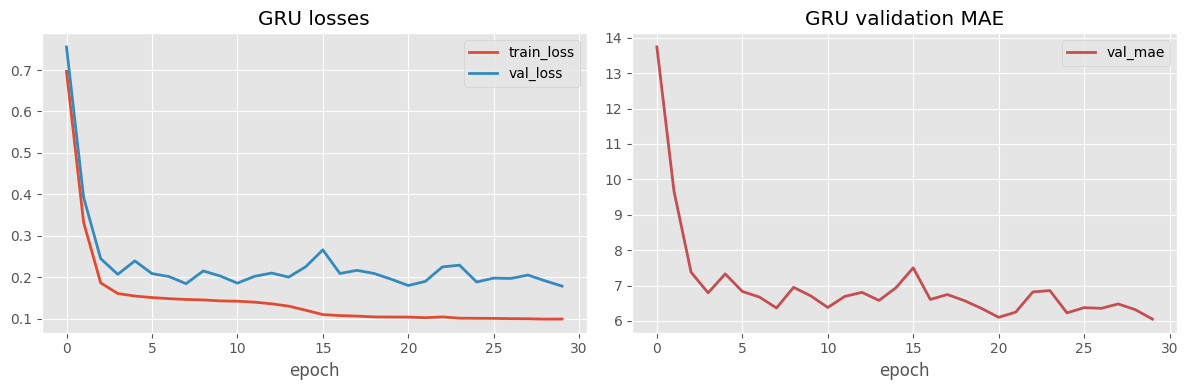

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(gru_history["train_loss"], label="train_loss", linewidth=2)
axes[0].plot(gru_history["val_loss"], label="val_loss", linewidth=2)
axes[0].set_title("GRU losses")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[1].plot(gru_history["val_mae"], label="val_mae", linewidth=2, color="#C44E52")
axes[1].set_title("GRU validation MAE")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gru_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Сравнение на validation и один финальный test лучшего подхода


In [14]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("best_val_mae").reset_index(drop=True)
results_df


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,R1,forecasting,S12-hw-dataset.csv,42,"{""train"": {""rows"": 3024, ""date_from"": ""2025-01...",24,1,GRU forecaster,past target window only,StandardScaler(train target only),Adam,0.001,30,6.050158,7.804417,4.053775,,,,"window_size=24, hidden_size=32"
1,B1,forecasting,S12-hw-dataset.csv,42,"{""train"": {""rows"": 3024, ""date_from"": ""2025-01...",,1,Naive last value,last observed target,none,,,,6.444815,8.201023,4.397922,,,,Prediction equals lag_1
2,B3,forecasting,S12-hw-dataset.csv,42,"{""train"": {""rows"": 3024, ""date_from"": ""2025-01...",,1,Ridge regression,"lag_1, lag_7, lag_14, rolling_mean_7, rolling_...",StandardScaler(train only),,,,6.734516,8.235854,4.514981,,,,"Lag, rolling and calendar features"
3,B2,forecasting,S12-hw-dataset.csv,42,"{""train"": {""rows"": 3024, ""date_from"": ""2025-01...",,1,Moving average (24),rolling mean over previous 24 points,none,,,,13.397980,16.169904,9.198834,,,,No training


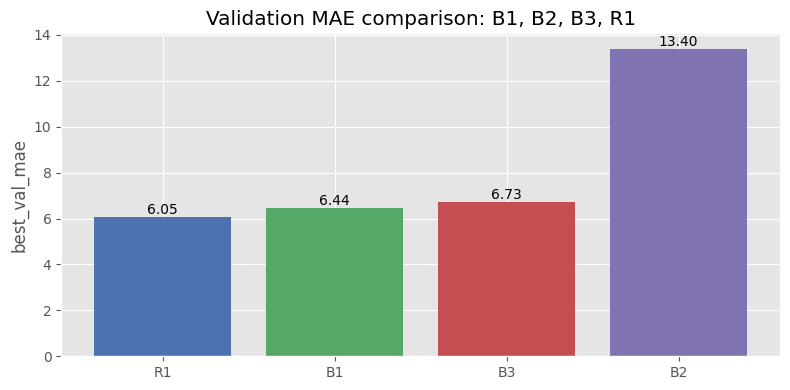

In [15]:
plt.figure(figsize=(8, 4))
plt.bar(results_df["experiment_id"], results_df["best_val_mae"], color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
plt.title("Validation MAE comparison: B1, B2, B3, R1")
plt.ylabel("best_val_mae")
for i, value in enumerate(results_df["best_val_mae"]):
    plt.text(i, value, f"{value:.2f}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baselines_compare.png", dpi=150, bbox_inches="tight")
plt.show()


In [16]:
best_experiment_id = results_df.iloc[0]["experiment_id"]
print("Best approach by validation MAE:", best_experiment_id)

if best_experiment_id == "B1":
    test_frame = feature_df.iloc[val_end:].dropna(subset=["naive_last_pred"])
    test_pred = test_frame["naive_last_pred"].to_numpy()
    test_true = test_frame["target"].to_numpy()
    test_dates = test_frame["date"].reset_index(drop=True)
elif best_experiment_id == "B2":
    test_frame = feature_df.iloc[val_end:].dropna(subset=["moving_average_pred"])
    test_pred = test_frame["moving_average_pred"].to_numpy()
    test_true = test_frame["target"].to_numpy()
    test_dates = test_frame["date"].reset_index(drop=True)
elif best_experiment_id == "B3":
    X_test = model_df.loc[test_mask, feature_columns].to_numpy()
    y_test = model_df.loc[test_mask, "target"].to_numpy()
    test_pred = ridge.predict(feature_scaler.transform(X_test))
    test_true = y_test
    test_dates = model_df.loc[test_mask, "date"].reset_index(drop=True)
else:
    _, _, test_pred, test_true = evaluate_gru(gru_model, test_loader, nn.MSELoss())
    test_dates = df.iloc[max(val_end, window_size):]["date"].reset_index(drop=True)

test_metrics = calc_metrics(test_true, test_pred)
print(test_metrics)

results_df.loc[results_df["experiment_id"] == best_experiment_id, "test_mae"] = test_metrics["mae"]
results_df.loc[results_df["experiment_id"] == best_experiment_id, "test_rmse"] = test_metrics["rmse"]
results_df.loc[results_df["experiment_id"] == best_experiment_id, "test_mape"] = test_metrics["mape"]


Best approach by validation MAE: R1
{'mae': 7.455414295196533, 'rmse': 9.540540825890757, 'mape': 4.75900936126709, 'smape': 4.897402763366699}


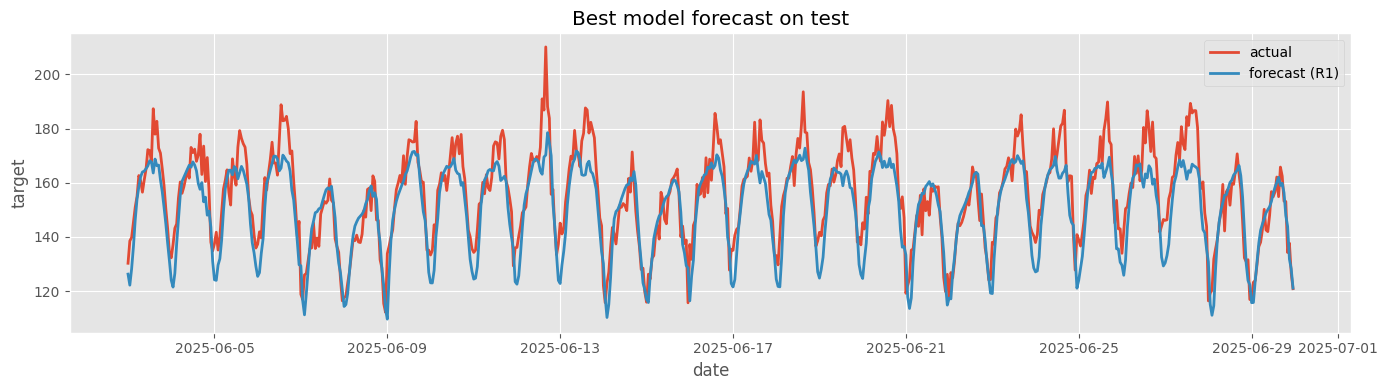

In [17]:
plt.figure(figsize=(14, 4))
plt.plot(test_dates, test_true, label="actual", linewidth=2)
plt.plot(test_dates, test_pred, label=f"forecast ({best_experiment_id})", linewidth=2)
plt.title("Best model forecast on test")
plt.xlabel("date")
plt.ylabel("target")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "best_forecast_test.png", dpi=150, bbox_inches="tight")
plt.show()


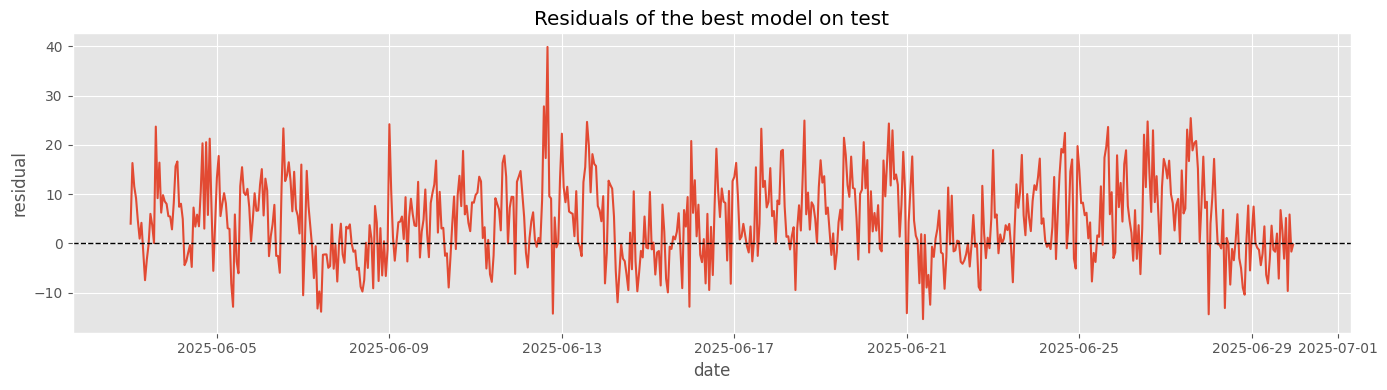

In [18]:
residuals = np.asarray(test_true) - np.asarray(test_pred)
plt.figure(figsize=(14, 4))
plt.plot(test_dates, residuals, linewidth=1.5)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Residuals of the best model on test")
plt.xlabel("date")
plt.ylabel("residual")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "residuals_best.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Сохранение обязательных артефактов


In [19]:
torch.save(gru_model.state_dict(), ARTIFACTS_DIR / "best_gru.pt")

best_gru_config = {
    "dataset": DATA_PATH.name,
    "seed": SEED,
    "window_size": window_size,
    "horizon": 1,
    "hidden_size": hidden_size,
    "num_layers": num_layers,
    "batch_size": batch_size,
    "learning_rate": learning_rate,
    "max_epochs": max_epochs,
    "optimizer": "Adam",
    "scaler": "StandardScaler(train target only)",
    "best_val_mae": float(result_r1["best_val_mae"]),
    "best_val_rmse": float(result_r1["best_val_rmse"]),
    "best_val_mape": float(result_r1["best_val_mape"]),
}

with open(ARTIFACTS_DIR / "best_gru_config.json", "w", encoding="utf-8") as f:
    json.dump(best_gru_config, f, indent=2, ensure_ascii=False)

csv_fields = [
    "experiment_id", "task", "dataset", "seed", "split_summary", "window_size", "horizon",
    "model_summary", "features_summary", "scaler", "optimizer", "lr", "epochs_trained",
    "best_val_mae", "best_val_rmse", "best_val_mape", "test_mae", "test_rmse", "test_mape", "notes"
]

with open(ARTIFACTS_DIR / "runs.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=csv_fields)
    writer.writeheader()
    for row in results_df.to_dict(orient="records"):
        writer.writerow({field: row.get(field, "") for field in csv_fields})

print(results_df[["experiment_id", "best_val_mae", "best_val_rmse", "best_val_mape", "test_mae"]])
print("Artifacts saved to:", ARTIFACTS_DIR.resolve())


  experiment_id  best_val_mae  best_val_rmse  best_val_mape  test_mae
0            R1      6.050158       7.804417       4.053775  7.455414
1            B1      6.444815       8.201023       4.397922          
2            B3      6.734516       8.235854       4.514981          
3            B2     13.397980      16.169904       9.198834          
Artifacts saved to: C:\Users\vt240\OneDrive\Рабочий стол\prog\II-cafedra\aie-student-template\homeworks\HW12\artifacts
